# Astrometry, WCS, and custom catalogs

Every simulated frame carries a gnomonic (TAN) WCS built by
`wcc_sim.wcsutil.build_wcs`. This notebook checks the WCS round-trip, verifies that
injected stars land where the WCS says they should (to milliarcseconds), demonstrates
position angles, and shows the edge / `in_image` bookkeeping.

**Requirements:** the `py313` conda env kernel. Fully offline (synthetic catalogs).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
import wcc_sim

plt.style.use('gks')
TEAL, RED, AMBER = '#00798c', '#d1495b', '#edae49'

print(f'wcc_sim {wcc_sim.__version__} | wcc_etc {wcc_etc.__version__}')

wcc_sim 0.1.0 | wcc_etc 0.6.0


## 1. The TAN WCS and its round-trip

`build_wcs(ra, dec, plate_scale_mas, pa, shape)` centers the projection on the array
center, with the conventional east-left parity and `pa` degrees E of N.

In [2]:
from wcc_sim.wcsutil import build_wcs

RA0, DEC0 = 291.0, 44.5
SHAPE = (512, 512)
PLATE = 16.87  # mas/px (IMX455)

w = build_wcs(RA0, DEC0, PLATE, 0.0, SHAPE)
print(repr(w))

rng = np.random.default_rng(0)
x = rng.uniform(0, SHAPE[1] - 1, 500)
y = rng.uniform(0, SHAPE[0] - 1, 500)
ra, dec = w.pixel_to_world_values(x, y)
x2, y2 = w.world_to_pixel_values(ra, dec)
err_px = np.hypot(x2 - x, y2 - y).max()
print(f'round-trip error: {err_px:.3e} px ({err_px * PLATE:.3e} mas)')
assert err_px < 1e-6

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 291.0 44.5 
CRPIX : 256.5 256.5 
CD1_1 CD1_2  : -4.686111111111111e-06 0.0 
CD2_1 CD2_2  : 0.0 4.686111111111111e-06 
NAXIS : 512  512
round-trip error: 1.009e-08 px (1.703e-07 mas)


## 2. Do stars land where the WCS says?

Inject a 7×7 grid of G = 15 stars (via `catalog=`, no Gaia query), simulate without
noise, and measure each star's centroid on the background-subtracted expectation
image. Rendering uses a fine-grid shift that is exact to 1/22 px (≈ 0.8 mas), so
centroids should agree with the catalog to milliarcseconds.

In [3]:
from astropy.table import Table
from wcc_sim import simulate_field

gx, gy = np.meshgrid(np.linspace(76, 436, 7), np.linspace(76, 436, 7))
gx = gx.ravel() + np.random.default_rng(1).uniform(-0.5, 0.5, gx.size)  # sub-pixel
gy = gy.ravel() + np.random.default_rng(2).uniform(-0.5, 0.5, gy.size)
ras, decs = w.pixel_to_world_values(gx, gy)
n = ras.size
cat = Table({
    'source_id': np.arange(n), 'ra': ras, 'dec': decs,
    'phot_g_mean_mag': np.full(n, 15.0),
    'phot_bp_mean_mag': np.full(n, np.nan),
    'phot_rp_mean_mag': np.full(n, np.nan),
})
field = simulate_field(RA0, DEC0, sensorfilter='zwo:r', focus=0, exptime=90,
                       catalog=cat, shape=SHAPE, add_noise=False)

bkg = (field.params['sky_e_s'] + field.params['dark_e_s']) * 90.0
img = field.image_clean - bkg

def centroid(img, x0, y0, half=8):
    xi, yi = int(round(x0)), int(round(y0))
    cut = img[yi - half:yi + half + 1, xi - half:xi + half + 1]
    yy, xx = np.mgrid[yi - half:yi + half + 1, xi - half:xi + half + 1]
    return (xx * cut).sum() / cut.sum(), (yy * cut).sum() / cut.sum()

cx, cy = np.array([centroid(img, *xy) for xy in zip(field.catalog['x'],
                                                    field.catalog['y'])]).T
dx = (cx - field.catalog['x']) * PLATE
dy = (cy - field.catalog['y']) * PLATE
print(f'centroid residuals: rms {np.hypot(dx, dy).std():.2f} mas, '
      f'max {np.hypot(dx, dy).max():.2f} mas')
assert np.hypot(dx, dy).max() < 0.2 * PLATE  # well below 1/5 pixel

centroid residuals: rms 0.21 mas, max 1.03 mas


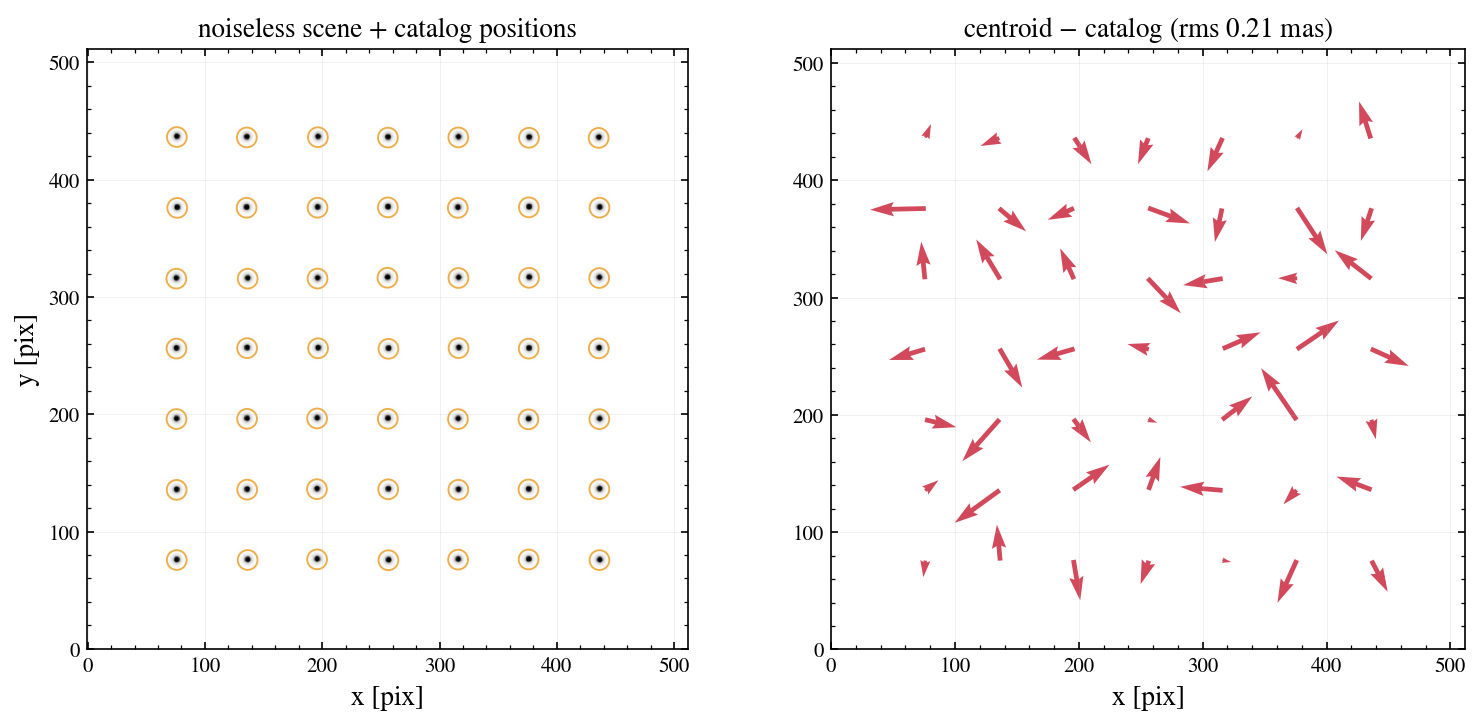

In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5.2))
from astropy.visualization import simple_norm
axL.imshow(field.image_clean, origin='lower', cmap='gray_r',
           norm=simple_norm(field.image_clean, 'asinh', percent=99.7))
axL.scatter(field.catalog['x'], field.catalog['y'], s=90, facecolor='none',
            edgecolor=AMBER, lw=0.9)
axL.set_xlabel('x [pix]'); axL.set_ylabel('y [pix]')
axL.set_title('noiseless scene + catalog positions')

axR.quiver(field.catalog['x'], field.catalog['y'], dx, dy,
           angles='xy', color=RED)
axR.set_xlim(0, SHAPE[1]); axR.set_ylim(0, SHAPE[0])
axR.set_xlabel('x [pix]')
axR.set_title(f'centroid $-$ catalog (rms {np.hypot(dx, dy).std():.2f} mas)')
plt.show()

## 3. Position angle

`pa` rotates the field on the detector (degrees E of N). Same sky scene, two roll
angles:

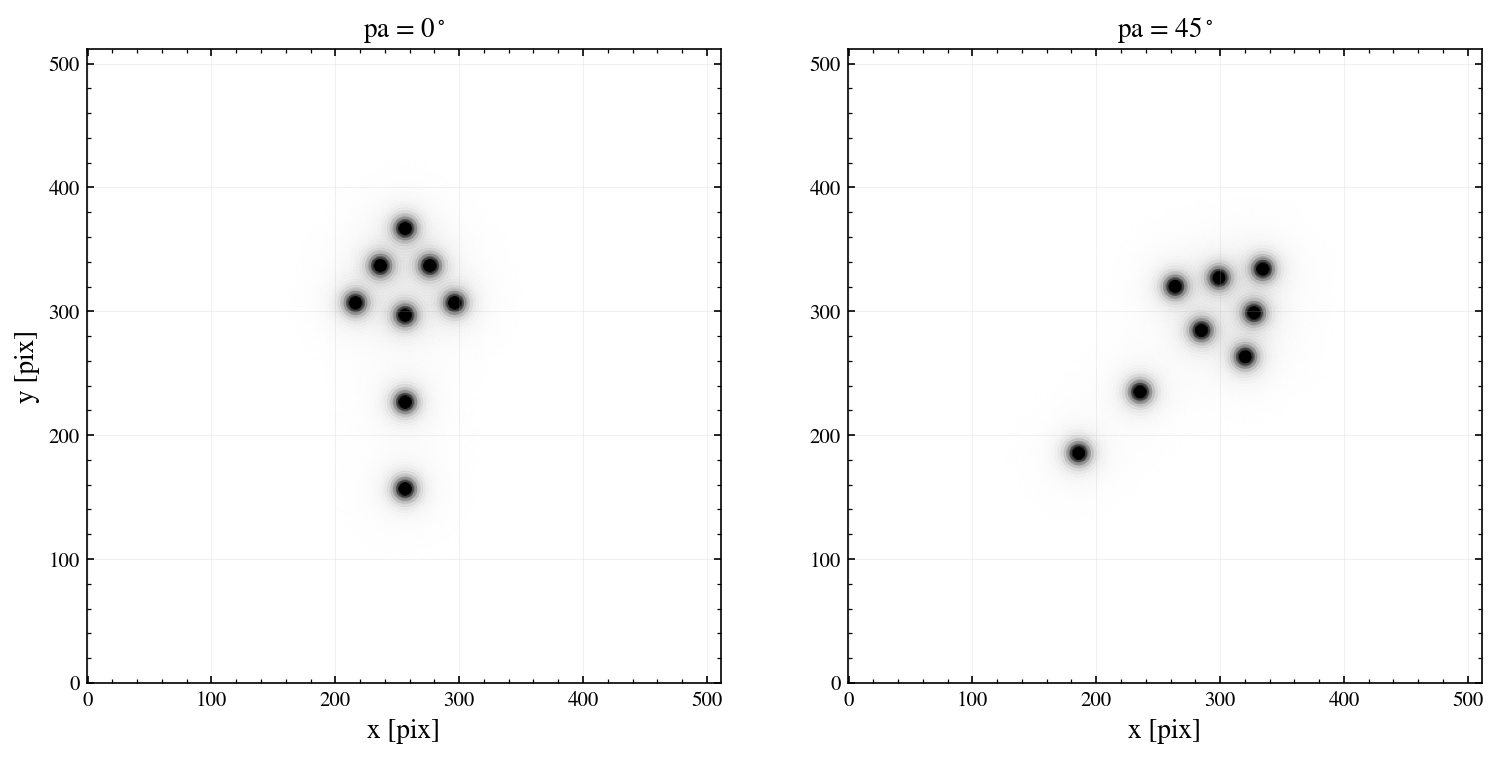

In [5]:
# An asymmetric pattern (an arrow) so the rotation is obvious.
ax_px = np.array([256, 256, 256, 256, 236, 276, 216, 296])
ay_px = np.array([156, 226, 296, 366, 336, 336, 306, 306])
ras, decs = w.pixel_to_world_values(ax_px, ay_px)
cat_arrow = Table({
    'source_id': np.arange(ras.size), 'ra': ras, 'dec': decs,
    'phot_g_mean_mag': np.full(ras.size, 13.0),
    'phot_bp_mean_mag': np.full(ras.size, np.nan),
    'phot_rp_mean_mag': np.full(ras.size, np.nan),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, pa in zip(axes, (0.0, 45.0)):
    f = simulate_field(RA0, DEC0, sensorfilter='zwo:r', focus=0, exptime=90,
                       pa=pa, seed=5, catalog=cat_arrow, shape=SHAPE)
    ax.imshow(f.image_adu, origin='lower', cmap='gray_r',
              norm=simple_norm(f.image_adu, 'asinh', percent=99.8))
    ax.set_title(f'pa = {pa:.0f}$^\circ$')
    ax.set_xlabel('x [pix]')
axes[0].set_ylabel('y [pix]')
plt.show()

## 4. Edges and the `in_image` flag

Stars whose centers fall off the array get `in_image = False` but still contribute
their PSF wings if they are close enough (the Gaia query radius includes a 10 arcsec
margin for exactly this reason).

In [6]:
xs_edge = np.array([-40.0, -8.0, 256.0, 519.0, 551.0])
ras, decs = w.pixel_to_world_values(xs_edge, np.full_like(xs_edge, 256.0))
cat_edge = Table({
    'source_id': np.arange(ras.size), 'ra': ras, 'dec': decs,
    'phot_g_mean_mag': np.full(ras.size, 11.0),
    'phot_bp_mean_mag': np.full(ras.size, np.nan),
    'phot_rp_mean_mag': np.full(ras.size, np.nan),
})
f = simulate_field(RA0, DEC0, sensorfilter='zwo:r', focus=0, exptime=90,
                   catalog=cat_edge, shape=SHAPE, add_noise=False)
for row in f.catalog:
    print(f"x = {row['x']:7.1f}  in_image = {bool(row['in_image'])}")
assert list(f.catalog['in_image']) == [False, False, True, False, False]

x =   -40.0  in_image = False
x =    -8.0  in_image = False
x =   256.0  in_image = True
x =   519.0  in_image = False
x =   551.0  in_image = False


## Summary

- The TAN WCS round-trips at floating-point precision; injected stars land on the
  detector to milliarcseconds (sub-pixel placement exact to 1/22 px).
- `pa` rolls the field; `in_image` marks stars whose centers are on the array, while
  off-edge stars still deposit their wings.